In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import functions

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
     ConfusionMatrixDisplay,
    classification_report
)

In [2]:
plt.style.use("ggplot")

### **Data Loading**

In [3]:
file_path = "data/test.csv"

test = pd.read_csv(file_path)
test.head()

,Team_Size,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Stakeholder_Count,Past_Similar_Projects,External_Dependencies_Count,Change_Request_Frequency,Team_Turnover_Rate,Vendor_Reliability_Score,...,Risk_Management_Maturity_Formal,Team_Colocation_Fully Colocated,Team_Colocation_Fully Remote,Team_Colocation_Hybrid,Team_Colocation_Partially Colocated,Documentation_Quality_Basic,Documentation_Quality_Excellent,Documentation_Quality_Good,Documentation_Quality_Poor,Risk_Level
0,-0.805976,-0.446876,-1.322728,-0.919120,-0.261801,0.002298,-0.075046,1.151044,-0.191081,0.837840,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,2
1,0.384205,-0.296844,0.551948,0.991467,-0.261801,0.002298,1.791380,-0.555362,0.772606,-0.323254,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1
2,0.276007,0.449088,0.407742,1.348291,-0.036535,1.699274,-0.075046,1.320836,0.411223,0.837840,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
3,-0.697778,-0.282622,-0.457493,0.214585,-0.712333,0.002298,-0.697188,-0.827029,0.411223,-0.139923,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,3
4,-1.022373,-0.722100,-0.890110,-0.955254,-0.261801,-1.129019,-1.319330,0.981253,0.591914,0.776730,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1


In [4]:
X_test = test.drop(columns=["Risk_Level"])
y_test = test["Risk_Level"].copy()

### **Model Evaluation**

,accuracy,precision,recall,f1-score
model,,,,
SVM,0.63500,0.636350,0.63500,0.635493
LogisticRegression,0.70000,0.702348,0.70000,0.698324
RandomForest,0.53875,0.569185,0.53875,0.523524


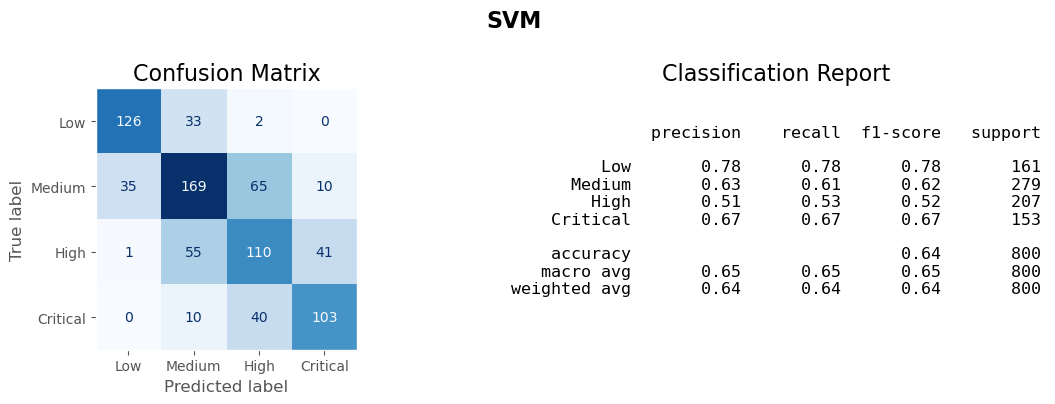

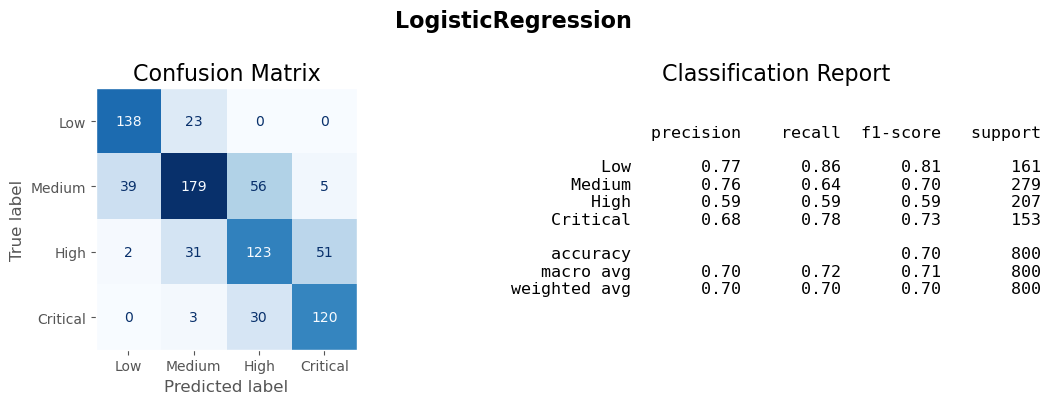

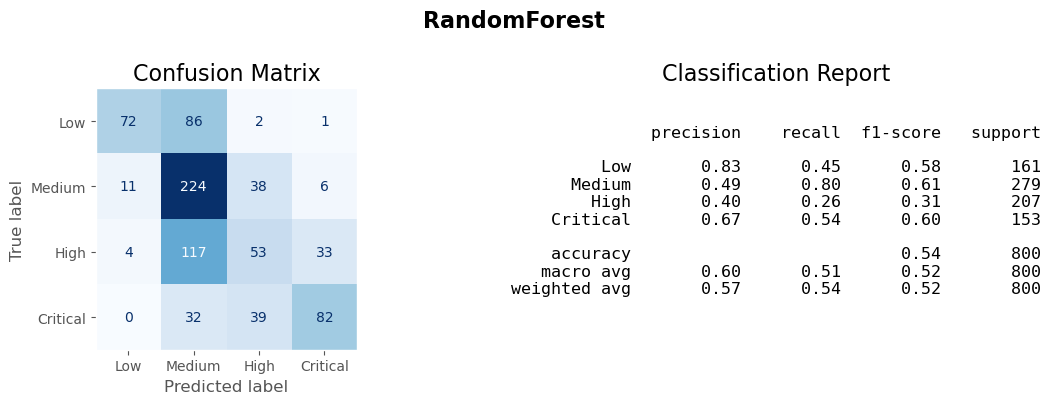

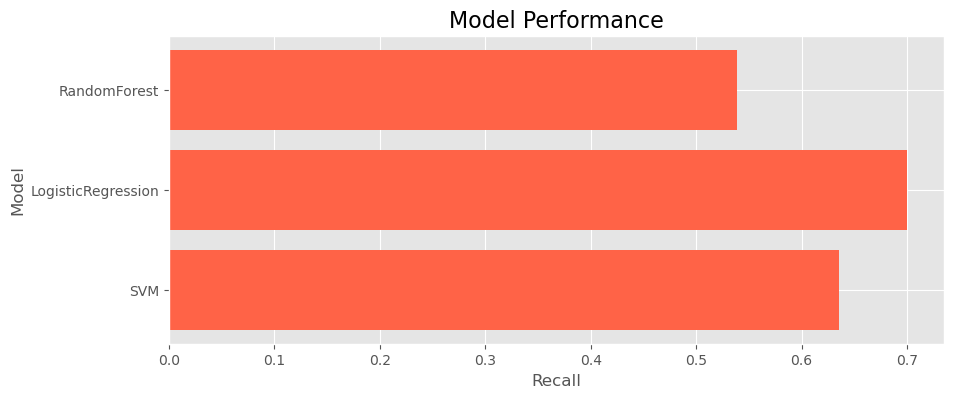

In [5]:
dir = "models"

results = []

for filename in os.listdir(dir):

    path = os.path.join(dir, filename)
    model_name = os.path.splitext(filename)[0]

    model = functions.load_model(path)
    y_pred, metrics = functions.evaluate_model(model, X_test, y_test)
    metrics["model"] = model_name
    results.append(metrics)

    functions.confusionMatrix(y_test, y_pred, model_name)

df_results = pd.DataFrame(results).set_index("model")
display(df_results)

plt.figure(figsize=(10, 4))
plt.barh(df_results.index, df_results["recall"], color="tomato")
plt.title("Model Performance", fontsize=16)
plt.xlabel("Recall")
plt.ylabel("Model")
plt.show()